In [8]:
import requests
import pandas as pd

url = "http://localhost/Chronology/fetch_data.php"
res = requests.get(url)
data = res.json()

df = pd.DataFrame(data)

df.columns = df.columns.str.lower()
df = df.rename(columns={
    "location": "location",
    "count": "crime_count",
    "counts": "crime_count"
})

print(df.head())

    id crime_id        date        day     month  year start_time  end_time  \
0  405     C267  2026-05-05    Tuesday       May  2026   12:39:00  15:39:00   
1  404     C278  2026-05-07   Thursday       May  2026   20:58:00  19:02:00   
2  403     C267  2026-04-29  Wednesday       Apr  2026   12:17:00  14:17:00   
3  402     C256  2026-05-07   Thursday       May  2026   18:01:00  19:06:00   
4  396     C250  2025-11-06   Thursday  November  2025   05:00:00  07:00:00   

   location crime_type crime_count  
0     murud   accident           2  
1     mahad     murder           8  
2     mahad   accident           4  
3    alibag      theft           8  
4  Revdanda    Robbery           3  


In [10]:
print(df.dtypes)

id             object
crime_id       object
date           object
day            object
month          object
year           object
start_time     object
end_time       object
location       object
crime_type     object
crime_count    object
dtype: object


In [11]:
print("Before cleaning:")
print(df.dtypes)

# STEP 1: force string cleanup
df['crime_count'] = df['crime_count'].astype(str)

# STEP 2: remove unwanted characters
df['crime_count'] = df['crime_count'].str.replace(r'[^0-9.]', '', regex=True)

# STEP 3: convert to numeric
df['crime_count'] = pd.to_numeric(df['crime_count'], errors='coerce')

# STEP 4: remove bad rows
df = df.dropna(subset=['crime_count'])

# STEP 5: convert to float
df['crime_count'] = df['crime_count'].astype(float)

print("\nAfter cleaning:")
print(df.dtypes)
print(df.head())

Before cleaning:
id             object
crime_id       object
date           object
day            object
month          object
year           object
start_time     object
end_time       object
location       object
crime_type     object
crime_count    object
dtype: object

After cleaning:
id              object
crime_id        object
date            object
day             object
month           object
year            object
start_time      object
end_time        object
location        object
crime_type      object
crime_count    float64
dtype: object
    id crime_id        date        day     month  year start_time  end_time  \
0  405     C267  2026-05-05    Tuesday       May  2026   12:39:00  15:39:00   
1  404     C278  2026-05-07   Thursday       May  2026   20:58:00  19:02:00   
2  403     C267  2026-04-29  Wednesday       Apr  2026   12:17:00  14:17:00   
3  402     C256  2026-05-07   Thursday       May  2026   18:01:00  19:06:00   
4  396     C250  2025-11-06   Thursday  November

In [13]:
import requests
import pandas as pd
import numpy as np

url = "http://localhost/Chronology/fetch_data.php"
res = requests.get(url)
data = res.json()

df = pd.DataFrame(data)
df.columns = df.columns.str.lower()

df = df.rename(columns={
    "location": "location",
    "locations": "location",
    "count": "crime_count",
    "counts": "crime_count"
})

print(df.head())

    id crime_id        date        day     month  year start_time  end_time  \
0  405     C267  2026-05-05    Tuesday       May  2026   12:39:00  15:39:00   
1  404     C278  2026-05-07   Thursday       May  2026   20:58:00  19:02:00   
2  403     C267  2026-04-29  Wednesday       Apr  2026   12:17:00  14:17:00   
3  402     C256  2026-05-07   Thursday       May  2026   18:01:00  19:06:00   
4  396     C250  2025-11-06   Thursday  November  2025   05:00:00  07:00:00   

   location crime_type crime_count  
0     murud   accident           2  
1     mahad     murder           8  
2     mahad   accident           4  
3    alibag      theft           8  
4  Revdanda    Robbery           3  


In [14]:
df['crime_count'] = pd.to_numeric(df['crime_count'], errors='coerce')
df = df.dropna(subset=['crime_count'])
df['crime_count'] = df['crime_count'].astype(float)

print(df.dtypes)

id              object
crime_id        object
date            object
day             object
month           object
year            object
start_time      object
end_time        object
location        object
crime_type      object
crime_count    float64
dtype: object


In [15]:
from sklearn.preprocessing import StandardScaler

X = df[['crime_count']].values

threshold = df['crime_count'].mean()
y = (df['crime_count'] > threshold).astype(int)

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC()
}


Logistic Regression
Accuracy: 100.0
Precision: 100.0
Recall: 100.0
F1: 100.0


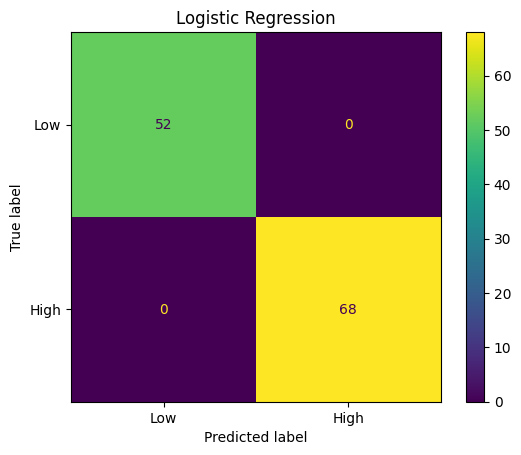


Decision Tree
Accuracy: 100.0
Precision: 100.0
Recall: 100.0
F1: 100.0


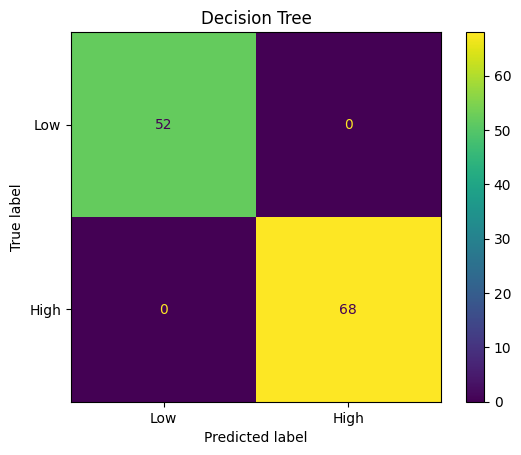


Random Forest
Accuracy: 100.0
Precision: 100.0
Recall: 100.0
F1: 100.0


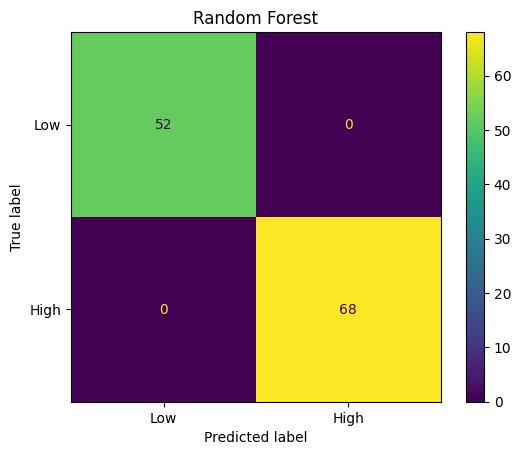


KNN
Accuracy: 100.0
Precision: 100.0
Recall: 100.0
F1: 100.0


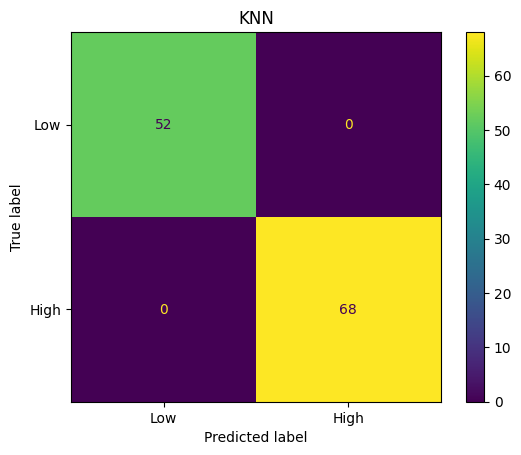


SVM
Accuracy: 100.0
Precision: 100.0
Recall: 100.0
F1: 100.0


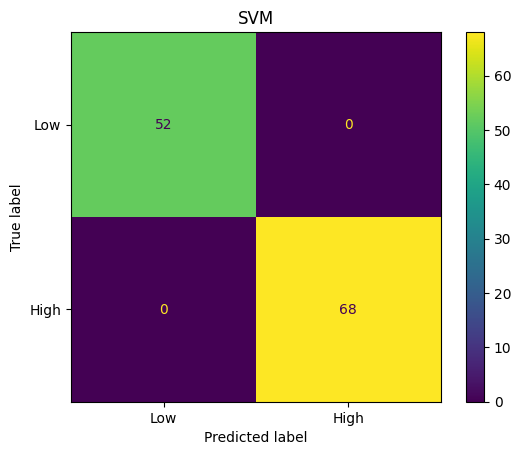

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

results = []

for name, model in models.items():

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred) * 100
    prec = precision_score(y_test, pred, zero_division=0) * 100
    rec = recall_score(y_test, pred, zero_division=0) * 100
    f1 = f1_score(y_test, pred, zero_division=0) * 100

    results.append([name, acc, prec, rec, f1])

    print("\n===================")
    print(name)
    print("===================")
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1:", f1)

    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=["Low","High"]).plot()
    plt.title(name)
    plt.show()

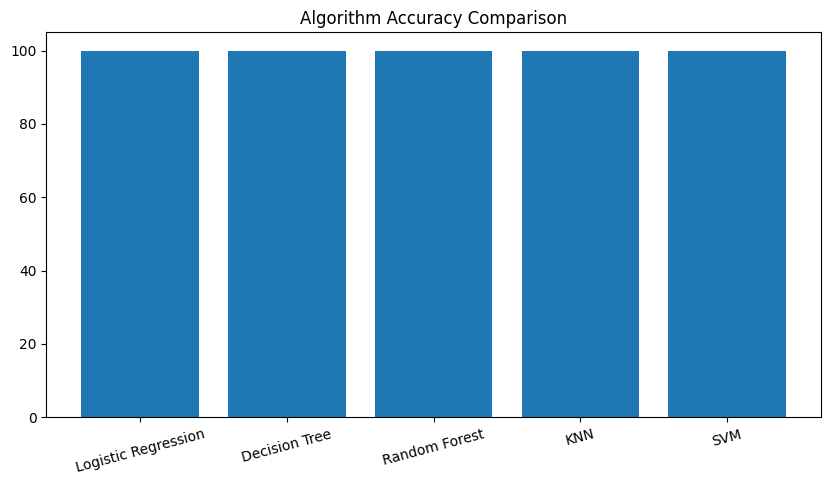

In [19]:
algos = [r[0] for r in results]
acc = [r[1] for r in results]

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(algos, acc)
plt.title("Algorithm Accuracy Comparison")
plt.xticks(rotation=15)
plt.show()